# 02 — Customer Segmentation (Clustering)
**Member B — Clustering Lead**

Compares **K-means**, **DBSCAN**, and **AGNES (Ward)** on log-transformed, standardised RFM features. Internal validation uses **Silhouette**, **Davies-Bouldin**, and **Calinski-Harabasz**. Final cluster labels for the chosen algorithm are saved for cross-task analysis (notebook 06).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from src.utils import seed_all, savefig, DATA_PROCESSED
from src.plot_style import apply_style, PALETTE
from src.features import build_clustering_matrix
from src import clustering as cl

seed_all(); apply_style()

In [2]:
rfm = pd.read_csv(DATA_PROCESSED / 'rfm_features.csv')
X, scaler, rfm_log = build_clustering_matrix(rfm)
print(f'Customers: {len(rfm):,}  |  feature dim: {X.shape[1]}')

Customers: 5,878  |  feature dim: 3


## 1. K-means — elbow + silhouette sweep

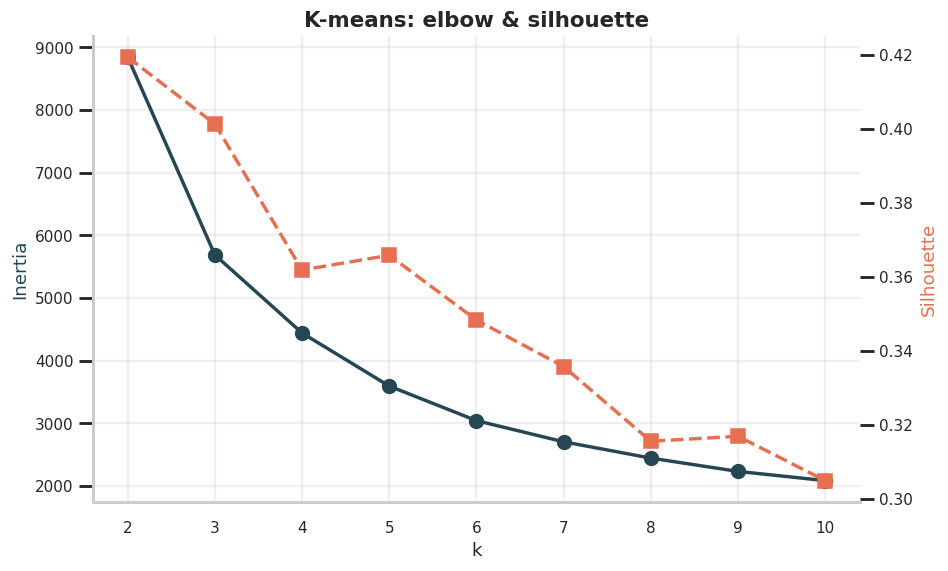

,k,inertia,silhouette
0,2,8844.092934,0.419339
1,3,5686.721385,0.401276
2,4,4440.785638,0.361882
3,5,3593.548277,0.365848
4,6,3042.055015,0.348363
5,7,2704.299767,0.335809
6,8,2444.096826,0.315653
7,9,2231.742461,0.316997
8,10,2084.839762,0.305028


In [3]:
sweep = cl.elbow_silhouette_search(X, k_range=range(2, 11))
fig, ax1 = plt.subplots()
ax1.plot(sweep['k'], sweep['inertia'], 'o-', color=PALETTE[0], label='Inertia')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia', color=PALETTE[0])
ax2 = ax1.twinx()
ax2.plot(sweep['k'], sweep['silhouette'], 's--', color=PALETTE[4], label='Silhouette')
ax2.set_ylabel('Silhouette', color=PALETTE[4]); ax2.grid(False)
plt.title('K-means: elbow & silhouette')
savefig(fig, '02_kmeans_sweep'); plt.show()
sweep

In [4]:
BEST_K = int(sweep.loc[sweep['silhouette'].idxmax(), 'k'])
print(f'Chosen k = {BEST_K} (max silhouette)')
km = cl.run_kmeans(X, k=BEST_K)
km

Chosen k = 2 (max silhouette)


ClusterResult(name='KMeans', labels=array([1, 1, 1, ..., 0, 0, 1]), n_clusters=2, silhouette=0.4193386085627426, davies_bouldin=0.8865137856123386, calinski_harabasz=5840.013582356018, extra={'inertia': 8844.092933958687, 'centers': array([[ 0.55595428, -0.69787043, -0.67987344],
       [-0.66068729,  0.8293382 ,  0.80795086]])})

## 2. DBSCAN — k-distance plot & fit

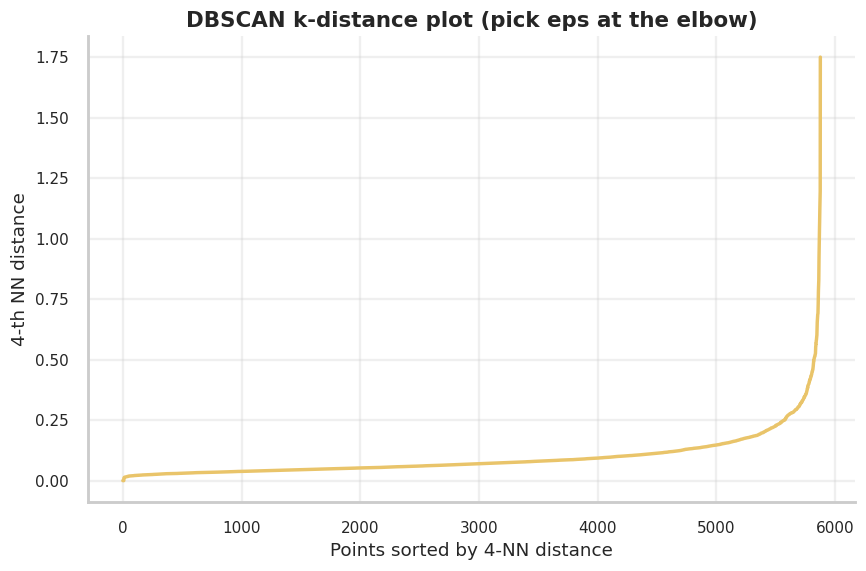

Heuristic eps = 0.202 (92nd percentile of 4-NN distances)


In [5]:
k4 = cl.k_distance_plot_values(X, k=4)
fig, ax = plt.subplots()
ax.plot(k4, color=PALETTE[2])
ax.set_xlabel('Points sorted by 4-NN distance'); ax.set_ylabel('4-th NN distance')
ax.set_title('DBSCAN k-distance plot (pick eps at the elbow)')
savefig(fig, '02_dbscan_kdist'); plt.show()
EPS = float(np.percentile(k4, 92))
print(f'Heuristic eps = {EPS:.3f} (92nd percentile of 4-NN distances)')

In [6]:
db = cl.run_dbscan(X, eps=EPS, min_samples=5)
db

ClusterResult(name='DBSCAN', labels=array([-1,  0,  0, ...,  2,  3,  0], dtype=int64), n_clusters=13, silhouette=-0.120453336801287, davies_bouldin=1.6319197286554359, calinski_harabasz=741.966603852737, extra={'eps': 0.20221103187005937, 'min_samples': 5, 'n_noise': 403})

## 3. AGNES (Ward) — dendrogram + fit

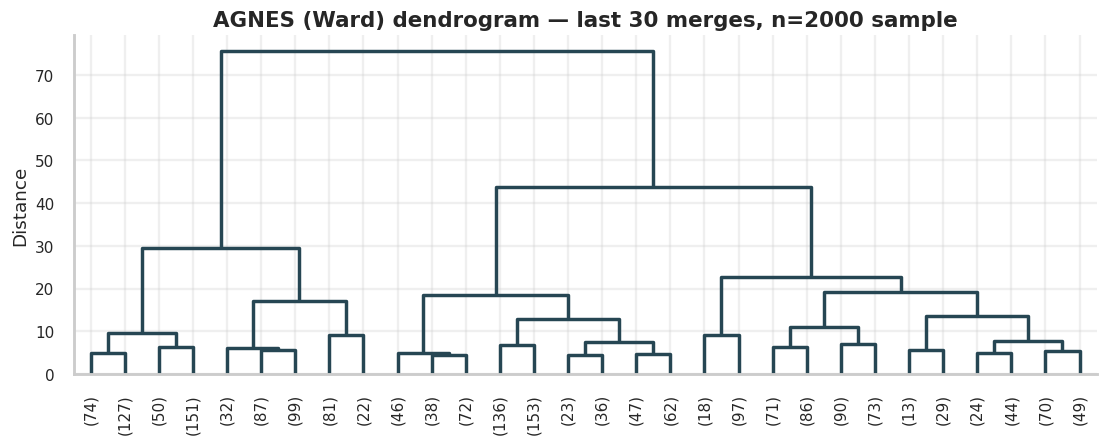

In [7]:
Z = linkage(X[:2000], method='ward')   # subsample for fast dendrogram
fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, ax=ax, color_threshold=0)
ax.set_title('AGNES (Ward) dendrogram — last 30 merges, n=2000 sample')
ax.set_ylabel('Distance')
savefig(fig, '02_dendrogram'); plt.show()

In [8]:
ag = cl.run_agnes(X, k=BEST_K)
ag

ClusterResult(name='AGNES', labels=array([0, 1, 0, ..., 0, 0, 1], dtype=int64), n_clusters=2, silhouette=0.3878230182943227, davies_bouldin=0.7886766155867594, calinski_harabasz=4303.976945038441, extra={'linkage': 'ward'})

## 4. Validation table

In [9]:
table = cl.results_table([km, db, ag]).round(4)
table.to_csv('../reports/clustering_validation.csv', index=False)
table

,Algorithm,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Notes
0,KMeans,2,0.4193,0.8865,5840.0136,"{'inertia': 8844.092933958687, 'centers': arra..."
1,DBSCAN,13,-0.1205,1.6319,741.9666,"{'eps': 0.20221103187005937, 'min_samples': 5,..."
2,AGNES,2,0.3878,0.7887,4303.9769,{'linkage': 'ward'}


## 5. 2-D visualisation (PCA + t-SNE)

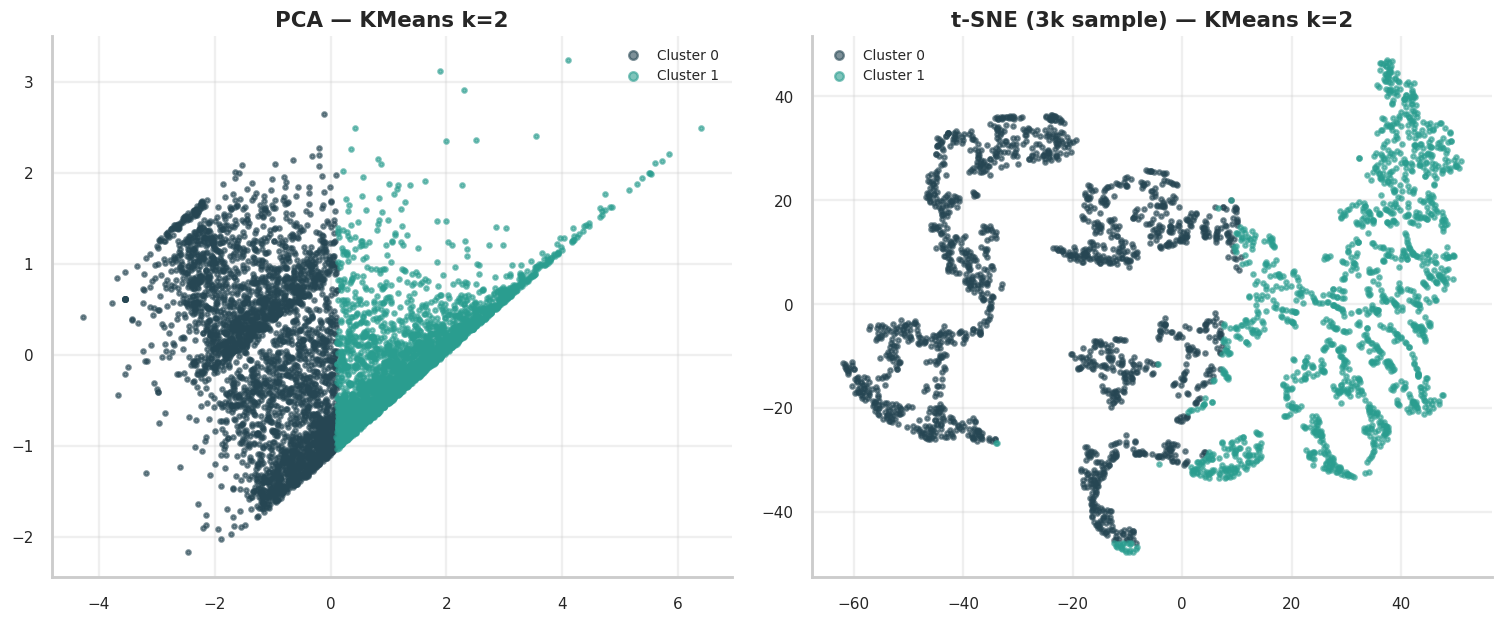

In [10]:
pca2 = PCA(n_components=2, random_state=42).fit_transform(X)
rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
tsne2 = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto',
             perplexity=40).fit_transform(X[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, labels, title in [
    (axes[0], pca2, km.labels, f'PCA — KMeans k={BEST_K}'),
    (axes[1], tsne2, km.labels[idx], f't-SNE (3k sample) — KMeans k={BEST_K}'),
]:
    for c in sorted(set(labels)):
        mask = labels == c
        ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.6,
                   color=PALETTE[c % len(PALETTE)], label=f'Cluster {c}')
    ax.set_title(title); ax.legend(markerscale=2, fontsize=9)
fig.tight_layout(); savefig(fig, '02_pca_tsne'); plt.show()

## 6. Cluster profiling — who is in each segment?

In [11]:
profile = cl.profile_clusters(rfm, km.labels)
profile.to_csv('../reports/cluster_profile_kmeans.csv', index=False)
profile

,cluster,n_customers,Recency_mean,Frequency_mean,Monetary_mean,share_%
0,0,3189,317.46,1.85,495.58,54.3
1,1,2689,62.60,11.55,5206.09,45.7


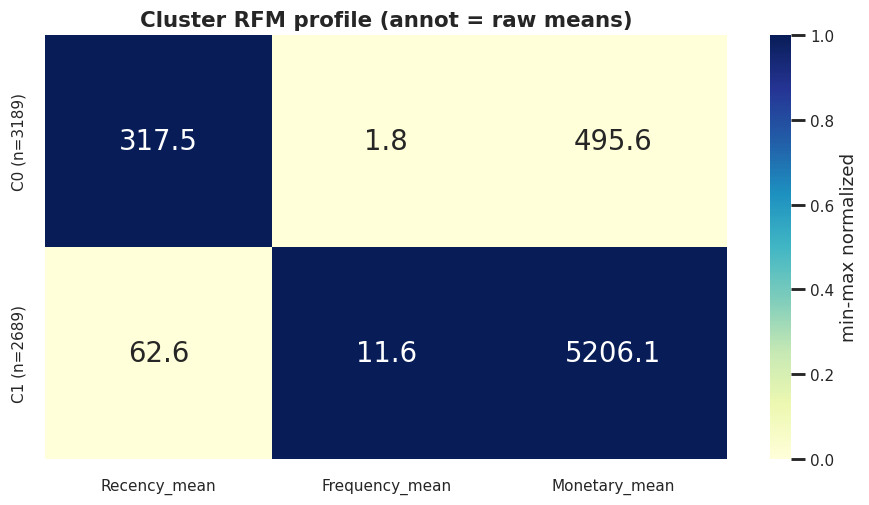

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
norm = profile[['Recency_mean','Frequency_mean','Monetary_mean']]
norm = (norm - norm.min()) / (norm.max() - norm.min())
sns.heatmap(norm, annot=profile[['Recency_mean','Frequency_mean','Monetary_mean']].round(1),
            yticklabels=[f'C{c} (n={n})' for c, n in zip(profile['cluster'], profile['n_customers'])],
            fmt='', cmap='YlGnBu', cbar_kws={'label': 'min-max normalized'}, ax=ax)
ax.set_title('Cluster RFM profile (annot = raw means)')
savefig(fig, '02_cluster_profile'); plt.show()

## 7. Persist cluster labels

In [13]:
for name, labels in [('kmeans', km.labels), ('dbscan', db.labels), ('agnes', ag.labels)]:
    out = rfm[['CustomerID']].copy(); out['cluster'] = labels
    out.to_csv(DATA_PROCESSED / f'segments_{name}.csv', index=False)
    print(f'  saved segments_{name}.csv  ({out["cluster"].nunique()} clusters)')

  saved segments_kmeans.csv  (2 clusters)
  saved segments_dbscan.csv  (14 clusters)
  saved segments_agnes.csv  (2 clusters)
